# Tutorial 7 · Nowcasting with pysteps

**Nowcasting** is forecasting precipitation from the last few observations, 0 to about
3 hours ahead, by moving the current rain field along its estimated motion. This tutorial
builds a nowcast step by step on open data, first by hand and then with
[pysteps](https://pysteps.readthedocs.io/en/stable/), the open-source nowcasting library
(Pulkkinen et al., 2019), and verifies it the way an operational centre would.

| | |
|---|---|
| **Data** | OpenRainER radar, Emilia-Romagna, 18 August 2022, 15-min rain depths (OpenSense example subset); OpenMRG radar and links, Gothenburg, 25 July 2015, 5 min |
| **You will learn** | the pysteps data model; optical flow by hand and in pysteps (LK, VET, DARTS, Proesmans); semi-Lagrangian extrapolation; the scale cascade behind S-PROG and STEPS; ANVIL and LINDA; ensembles; verification (CSI, FSS, SAL, CRPS, ROC, reliability, rank histogram); why a link map is hard to nowcast; advection interpolation for accumulations |
| **Runtime** | about 3 minutes on a laptop CPU (LINDA is the slowest single step) |
| **Prerequisites** | tutorial 04 (radar) and 05 (rain maps) help, but are not required |

It follows the [nowcasting session of the OpenSense 2025 training school](https://github.com/OpenSenseAction/TrainingSchoolMergingApplication/tree/main/nowcasting-session)
(J. Ritvanen and R. Imhoff), and the study built on it in
[`projects/os_nowcasting`](../projects/os_nowcasting/README.md), which runs the same methods over
many storms.

**Contents**
1. Nowcasting in one page
2. The data and the pysteps data model
3. Transforming rain rates
4. Optical flow by hand
5. Optical flow in pysteps
6. Semi-Lagrangian extrapolation
7. Rain from outside the domain: the verifiable area
8. The scale cascade and S-PROG
9. ANVIL and LINDA
10. Verifying deterministic nowcasts over many issue times
11. Ensembles with STEPS and how to verify them
12. Nowcasting a link map
13. Advection interpolation for accumulations
14. Summary
15. References and links

## 0. Setup

The notebook finds the repository root, so it runs from any working directory. The example
subsets download on first use (OpenRainER radar 16 MB, OpenMRG 28 MB) into the shared data
store described in [`DATA.md`](../DATA.md).

In [1]:
import contextlib, io, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from core.opensense import example_data
from pysteps import motion, nowcasts, verification
from pysteps.cascade.bandpass_filters import filter_gaussian
from pysteps.cascade.decomposition import decomposition_fft
from pysteps.extrapolation.semilagrangian import extrapolate
from pysteps.postprocessing.ensemblestats import excprob
from pysteps.utils import transformation
from pysteps.visualization import plot_precip_field, quiver


@contextlib.contextmanager
def quiet():
    # pysteps prints progress for most methods; keep the notebook readable
    with contextlib.redirect_stdout(io.StringIO()):
        yield

plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 10})
T0 = time.time()

## 1. Nowcasting in one page

**Lagrangian persistence.** Over the next hour, a rain field mostly *moves*; it grows and
decays more slowly than it travels. The simplest skilful nowcast keeps the last field
$R(\mathbf{x}, t_0)$ unchanged in a frame that moves with the rain:

$$\hat R(\mathbf{x}, t_0 + \tau) = R\big(\mathbf{x} - \boldsymbol{\alpha}(\mathbf{x}, \tau),\, t_0\big),$$

where $\boldsymbol{\alpha}$ is the displacement along the motion field $\mathbf{V}$ over the
lead time $\tau$. Three questions follow, and they structure this notebook:

1. **Motion**: how to estimate $\mathbf{V}$ from a few images (optical flow, sections 4–5).
2. **Advection**: how to move the field along $\mathbf{V}$ (semi-Lagrangian scheme, section 6).
3. **Evolution**: how to account for growth and decay, which advection ignores.

**Predictability depends on scale.** Germann and Zawadzki (2002) showed that the lifetime
of a precipitation feature in the Lagrangian frame grows with its size: small convective
cells decorrelate within minutes, large stratiform areas persist for hours. S-PROG (Seed,
2003) uses this by decomposing the field into a *cascade* of spatial scales and letting
each scale lose its predictability at its own rate. STEPS (Bowler et al., 2006; Seed et
al., 2013) adds stochastic noise at the scales that have become unpredictable, which
produces an *ensemble* of plausible futures instead of one smooth forecast.

## 2. The data and the pysteps data model

**OpenRainER** (Covi & Roversi, [doi:10.5281/zenodo.10593848](https://doi.org/10.5281/zenodo.10593848))
publishes the ARPAE radar composite of Emilia-Romagna as **15-minute rain depths** (mm)
on a 1 km grid, each stamped at the **end** of its interval. We take the morning of
18 August 2022, a widespread convective event, from the OpenSense example subset, and
average to 2 km pixels, which halves the run time without changing the picture.

pysteps works on plain NumPy arrays shaped `(time, y, x)` plus a **metadata dictionary**
that says what the numbers mean. Units: pysteps' methods expect rain *rates* (mm/h).
FieldSense's loader has already converted the 15-minute depths to mm/h (×4) and recorded
it in the variable's attributes; always check those before converting again.

In [2]:
radar = example_data.load("openrainer", "8d", components=("radar",))["radar"]
print({k: radar["R"].attrs[k] for k in ("units", "accum_time_h", "comment")}, "| grid", dict(radar["R"].sizes))

event = radar["R"].sel(time=slice("2022-08-18T00:00", "2022-08-18T14:00"))
event = event.coarsen(x=2, y=2, boundary="trim").mean()          # 1 km -> 2 km pixels
times = pd.DatetimeIndex(event.time.values)
rate_raw = event.values                                             # already mm/h (see attrs)
print(f"{len(times)} fields, {times[0]} to {times[-1]}, grid {rate_raw.shape[1:]}, "
      f"missing {np.isnan(rate_raw).mean():.3%}")
rate = np.where(np.isfinite(rate_raw), rate_raw, 0.0)              # a few edge pixels only

  [skip]  openrainer_cml_8d.nc  (0.83 MB, already present)


  [skip]  openrainer_radar_8d.nc  (15.98 MB, already present)


  [skip]  openrainer_gauges_8d.nc  (0.13 MB, already present)


{'units': 'mm h-1', 'accum_time_h': np.float64(0.25), 'comment': 'converted from 0.25 h accumulation in mm'} | grid {'time': 768, 'y': 290, 'x': 373}
57 fields, 2022-08-18 00:00:00 to 2022-08-18 14:00:00, grid (145, 186), missing 0.072%


The metadata dictionary: the corner coordinates and pixel size in the grid's projection
(here UTM 32N, metres), where row 0 lies (`yorigin`), the accumulation time and the unit,
and the threshold below which rain is treated as zero. `plot_precip_field` and the
nowcasting methods read it; getting `xpixelsize` and `yorigin` right matters, because
motion is estimated in pixels and converted with them.

{'xpixelsize': 2004.2504248274531, 'yorigin': 'lower', 'accutime': 15.0, 'unit': 'mm/h', 'threshold': 0.1}


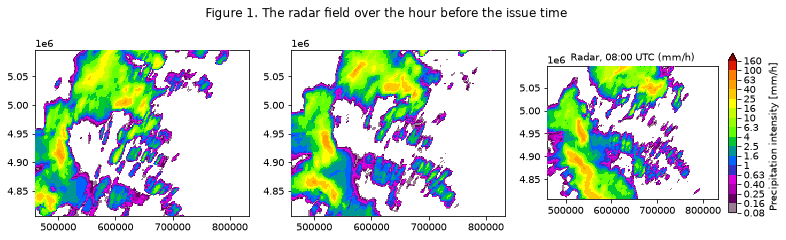

In [3]:
x, y = event.x.values, event.y.values
px = float(np.diff(x).mean())
metadata = {
    "projection": "EPSG:32632", "cartesian_unit": "m",
    "x1": x.min() - px / 2, "x2": x.max() + px / 2,
    "y1": y.min() - px / 2, "y2": y.max() + px / 2,
    "xpixelsize": px, "ypixelsize": px,
    "yorigin": "lower" if y[1] > y[0] else "upper",   # here row 0 is the southernmost row
    "accutime": 15.0, "unit": "mm/h", "transform": None,
    "threshold": 0.1, "zerovalue": 0.0, "zr_a": 200.0, "zr_b": 1.6,
    "timestamps": list(times.to_pydatetime()),
    "institution": "ARPAE-SIMC (OpenRainER)",
}
KM = px / 1000.0
STEP_MIN = 15
print({k: metadata[k] for k in ("xpixelsize", "yorigin", "accutime", "unit", "threshold")})

i0 = times.get_loc(pd.Timestamp("2022-08-18T08:00"))          # the issue time used below
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, k in zip(axes, (i0 - 4, i0 - 2, i0)):
    plot_precip_field(rate[k], geodata=metadata, ax=ax, colorbar=ax is axes[-1],
                      title=f"Radar, {times[k]:%H:%M} UTC (mm/h)")
fig.suptitle("Figure 1. The radar field over the hour before the issue time")
plt.show()

## 3. Transforming rain rates

Rain rates are zero over most of the domain and heavily skewed where it rains. Optical
flow and the autoregressive models in S-PROG and STEPS assume something closer to a
Gaussian field, so pysteps works in **decibels of rain rate** (dBR):

$$\mathrm{dBR} = 10 \log_{10} R \quad (R \ge R_{\min}), \qquad \mathrm{dBR} = z_0 \quad (R < R_{\min}),$$

with $R_{\min} = 0.1$ mm/h and a fill value $z_0 = -15$ dBR for dry pixels, as in the
training school.

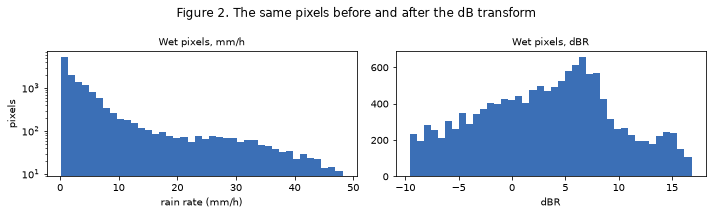

In [4]:
dbr, metadata_db = transformation.dB_transform(rate, metadata, threshold=0.1, zerovalue=-15.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
wet = rate[i0][rate[i0] > 0.1]
axes[0].hist(wet, bins=40, color="#3b6fb6"); axes[0].set_yscale("log")
axes[0].set(xlabel="rain rate (mm/h)", ylabel="pixels", title="Wet pixels, mm/h")
axes[1].hist(dbr[i0][rate[i0] > 0.1], bins=40, color="#3b6fb6")
axes[1].set(xlabel="dBR", title="Wet pixels, dBR")
fig.suptitle("Figure 2. The same pixels before and after the dB transform")
plt.tight_layout(); plt.show()

## 4. Optical flow by hand

Before calling pysteps, we estimate motion ourselves on a synthetic field whose motion we
know: a smooth random "rain" pattern moved by $(u, v) = (+3, -2)$ pixels, i.e. 3 columns
right and 2 rows down the array.

**Block matching** tries every integer displacement and keeps the one that best maps the
first image onto the second. **Lucas–Kanade** linearises brightness constancy,
$I(\mathbf{x} + \mathbf{d}, t+1) = I(\mathbf{x}, t)$, into

$$I_x u + I_y v + I_t = 0,$$

one equation per pixel for two unknowns, and solves it by least squares over a window:

$$\begin{pmatrix} \sum I_x^2 & \sum I_x I_y \\ \sum I_x I_y & \sum I_y^2 \end{pmatrix}
\begin{pmatrix} u \\ v \end{pmatrix} = -\begin{pmatrix} \sum I_x I_t \\ \sum I_y I_t \end{pmatrix}.$$

The linearisation holds for small shifts, so we iterate: warp the second image back by the
current estimate and solve for the remainder.

In [5]:
rng = np.random.default_rng(0)
f1 = np.clip(40 * ndimage.gaussian_filter(rng.normal(size=(120, 120)), 6), 0, None)
TRUE_U, TRUE_V = 3.0, -2.0                                  # columns, rows
f2 = ndimage.shift(f1, (TRUE_V, TRUE_U), order=1)


def block_matching(a, b, max_shift=6):
    best, best_err = (0, 0), np.inf
    core = (slice(max_shift, -max_shift),) * 2              # ignore the wrapped border
    for dv in range(-max_shift, max_shift + 1):
        for du in range(-max_shift, max_shift + 1):
            err = np.mean((np.roll(a, (dv, du), axis=(0, 1))[core] - b[core]) ** 2)
            if err < best_err:
                best, best_err = (du, dv), err
    return best


def lucas_kanade_global(a, b, n_iter=5):
    u = v = 0.0
    iy, ix = np.gradient(a)
    for _ in range(n_iter):
        b_back = ndimage.shift(b, (-v, -u), order=1)        # undo the motion found so far
        it = b_back - a
        A = np.array([[np.sum(ix * ix), np.sum(ix * iy)], [np.sum(ix * iy), np.sum(iy * iy)]])
        du, dv = np.linalg.solve(A, -np.array([np.sum(ix * it), np.sum(iy * it)]))
        u, v = u + du, v + dv
    return u, v


print("truth              u = %+.2f  v = %+.2f" % (TRUE_U, TRUE_V))
print("block matching     u = %+d     v = %+d" % block_matching(f1, f2))
print("Lucas-Kanade (own) u = %+.2f  v = %+.2f" % lucas_kanade_global(f1, f2))
V_syn = motion.get_method("LK")(np.stack([f1, f2]), verbose=False)
print("pysteps LK         u = %+.2f  v = %+.2f (median of the dense field)"
      % (np.nanmedian(V_syn[0]), np.nanmedian(V_syn[1])))

truth              u = +3.00  v = -2.00
block matching     u = +3     v = -2
Lucas-Kanade (own) u = +3.14  v = -1.76
pysteps LK         u = +3.01  v = -1.99 (median of the dense field)


All three recover the motion. Two conventions to remember: pysteps returns a dense field
`V` of shape `(2, y, x)` with `V[0]` the displacement along columns (x) and `V[1]` along
rows (y), in **pixels per time step**. The pysteps Lucas–Kanade is the *local* version of
the method above (Bouguet, 2001): it tracks features (corners of strong gradient) with
OpenCV's pyramidal LK, removes outliers, and interpolates the sparse vectors to a dense
field.

## 5. Optical flow in pysteps

pysteps offers several methods behind one interface, `motion.get_method(name)`:

| method | idea | inputs used here |
|---|---|---|
| `LK` | sparse Lucas–Kanade feature tracking, interpolated to a dense field (Bouguet, 2001) | 4 fields |
| `VET` | variational echo tracking: minimise the warping error plus a smoothness penalty (Laroche & Zawadzki, 1995) | 3 fields |
| `DARTS` | motion in the Fourier domain, fitted to a few wavenumbers (Ruzanski et al., 2011) | 8 fields |
| `proesmans` | dense optical flow with anisotropic diffusion (Proesmans et al., 1994) | 2 fields |

Motion is estimated on dBR fields, as recommended in the session. We also run LK on raw
rates to see what the transform changes.

LK         mean u +3.75 v +7.69 px/step =  68.6 km/h   (0.1 s)


VET        mean u +3.87 v +7.95 px/step =  70.9 km/h   (2.8 s)


DARTS      mean u +0.70 v +1.12 px/step =  10.6 km/h   (1.4 s)


proesmans  mean u +4.56 v +5.11 px/step =  54.9 km/h   (0.5 s)
LK on raw mm/h: mean u +4.36 v +6.71 px/step


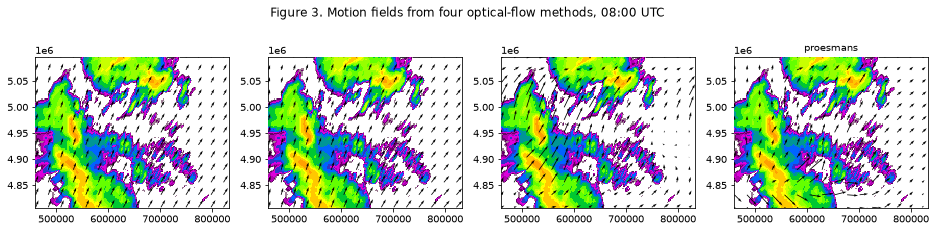

In [6]:
N_PAST = {"LK": 4, "VET": 3, "DARTS": 8, "proesmans": 2}
fields = {}
for name, n in N_PAST.items():
    t = time.time()
    with quiet():
        V = motion.get_method(name)(dbr[i0 - n + 1:i0 + 1], **({} if name == "proesmans" else {"verbose": False}))
    fields[name] = np.asarray(V[:2] if V.shape[0] == 2 else V[0][:2])
    u, v = np.nanmean(fields[name], axis=(1, 2))
    speed = np.hypot(u, v) * KM * 60 / STEP_MIN
    print(f"{name:10s} mean u {u:+.2f} v {v:+.2f} px/step = {speed:5.1f} km/h   ({time.time() - t:.1f} s)")
with quiet():
    V_raw = motion.get_method("LK")(rate[i0 - 3:i0 + 1], verbose=False)
print("LK on raw mm/h: mean u %+.2f v %+.2f px/step" % tuple(np.nanmean(V_raw, axis=(1, 2))))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (name, V) in zip(axes, fields.items()):
    plot_precip_field(rate[i0], geodata=metadata, ax=ax, colorbar=False, title=name)
    quiver(V, geodata=metadata, ax=ax, step=12)
fig.suptitle("Figure 3. Motion fields from four optical-flow methods, 08:00 UTC")
plt.show()
V_lk = fields["LK"]

LK, VET and Proesmans agree on a fast motion towards the north-north-east, 55–70 km/h:
this storm system crossed the region quickly. DARTS with its default number of Fourier
terms finds almost no motion on this grid (the training school noted that it needs
tuning, with artificial rotation in dry areas). LK is the fastest and the usual default;
on raw rates instead of dBR its mean vector changes by about one pixel per step, since
the strongest cells then dominate the tracking. In `projects/os_nowcasting`, LK, VET and
Proesmans give nowcasts within 0.01–0.03 CSI of each other over nine storms, and DARTS
0.06–0.10 lower.

## 6. Semi-Lagrangian extrapolation

The **semi-Lagrangian** scheme computes, for every output pixel, where its air parcel came
from, and samples the last field there (a *backward* trajectory). With a constant motion
the displacement is simply $\boldsymbol{\alpha} = \tau \mathbf{V}$, and a few lines of
SciPy do it. pysteps' `extrapolate` integrates the trajectory through the spatially
varying field in sub-steps (Germann & Zawadzki, 2002), which matters where motion rotates
or converges.

+30 min  MAE against observed: uniform motion 2.57 mm/h, pysteps 2.58 mm/h
+60 min  MAE against observed: uniform motion 3.33 mm/h, pysteps 3.43 mm/h
+90 min  MAE against observed: uniform motion 3.82 mm/h, pysteps 4.00 mm/h


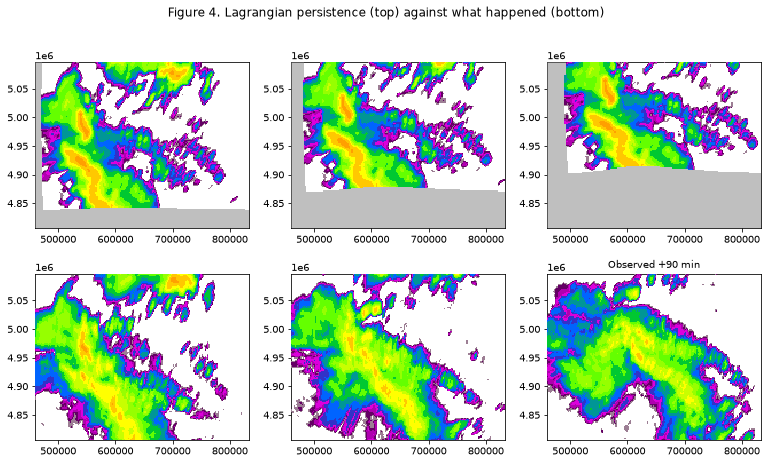

In [7]:
N_LEAD = 6                                               # 6 x 15 min = 90 min
ny, nx = rate.shape[1:]
yy, xx = np.mgrid[0:ny, 0:nx].astype(float)


def advect_constant(field, V, lead):
    # backward trajectory with the field's motion taken as uniform
    u, v = np.nanmean(V[0]), np.nanmean(V[1])
    return ndimage.map_coordinates(field, [yy - lead * v, xx - lead * u], order=1, cval=np.nan)


own = np.stack([advect_constant(rate[i0], V_lk, k) for k in range(1, N_LEAD + 1)])
with quiet():
    sl = extrapolate(rate[i0], V_lk, N_LEAD, allow_nonfinite_values=True)
obs = rate[i0 + 1:i0 + 1 + N_LEAD]
for k in (1, 3, 5):
    ok = np.isfinite(own[k]) & np.isfinite(sl[k])
    print(f"+{(k + 1) * STEP_MIN:2d} min  MAE against observed: uniform motion "
          f"{np.mean(np.abs(own[k] - obs[k])[ok]):.2f} mm/h, pysteps {np.mean(np.abs(sl[k] - obs[k])[ok]):.2f} mm/h")

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for j, k in enumerate((1, 3, 5)):
    plot_precip_field(sl[k], geodata=metadata, ax=axes[0, j], colorbar=False,
                      title=f"Extrapolation +{(k + 1) * STEP_MIN} min")
    plot_precip_field(obs[k], geodata=metadata, ax=axes[1, j], colorbar=False,
                      title=f"Observed +{(k + 1) * STEP_MIN} min")
fig.suptitle("Figure 4. Lagrangian persistence (top) against what happened (bottom)")
plt.show()

With motion this uniform, the shortcut and pysteps' trajectory integration give nearly the
same error; they part where the motion field rotates or converges.

## 7. Rain from outside the domain: the verifiable area

Extrapolation leaves **blank cells on the upwind edge**: their backward trajectory leaves
the domain, so no method can know what rain will arrive there. If those cells are scored
as "no rain forecast", every method is penalised for rain it could never have seen, and
the penalty grows with lead time and wind speed. On OpenMRG's small domain this made
Eulerian persistence look better than extrapolation in a first version of
`projects/os_nowcasting`.

The fix used there, and below: extrapolate a field of ones with the same motion; the cells
that stay finite are the ones reachable from inside the domain. All methods are scored on
that mask only.

verifiable share of the domain by lead (min): {15: '92%', 30: '85%', 45: '79%', 60: '72%', 75: '66%', 90: '59%'}


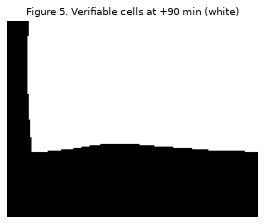

In [8]:
def reachable(V, shape, n_lead):
    with quiet():
        return np.isfinite(extrapolate(np.ones(shape), V, n_lead, allow_nonfinite_values=True))


mask = reachable(V_lk, rate.shape[1:], N_LEAD)
print("verifiable share of the domain by lead (min):",
      {(k + 1) * STEP_MIN: f"{mask[k].mean():.0%}" for k in range(N_LEAD)})
fig, ax = plt.subplots(figsize=(4.5, 3.6))
ax.imshow(mask[-1], origin="lower", cmap="Greys_r")
ax.set_title("Figure 5. Verifiable cells at +90 min (white)"); ax.axis("off")
plt.show()

## 8. The scale cascade and S-PROG

S-PROG splits the dBR field into $L$ spatial-scale bands with Gaussian band-pass filters
in Fourier space, $\mathrm{dBR} = \sum_{l=1}^{L} X_l$, and models each level in the
Lagrangian frame as a second-order autoregressive process,

$$X_l(t) = \phi_{l,1} X_l(t-1) + \phi_{l,2} X_l(t-2) + \varepsilon_l(t).$$

The deterministic forecast drops the noise term, so each level decays towards zero at its
own rate: small scales vanish quickly, large ones persist. The pattern smooths with lead
time, exactly as predictability is lost; pysteps then remaps the result to the observed
intensity distribution (CDF probability matching, on by default), so the peaks keep
realistic values. Below we decompose the field and measure each
level's lag-1 correlation after advecting the previous field to the current time.

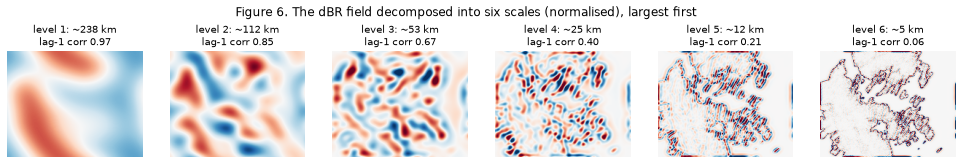

In [9]:
N_LEVELS = 6
filt = filter_gaussian(rate.shape[1:], N_LEVELS)
with quiet():
    prev_adv = extrapolate(dbr[i0 - 1], V_lk, 1, allow_nonfinite_values=True)[0]
prev_adv = np.where(np.isfinite(prev_adv), prev_adv, -15.0)
dec_now = decomposition_fft(dbr[i0], filt, normalize=True, compute_stats=True)
dec_prev = decomposition_fft(prev_adv, filt, normalize=True, compute_stats=True)

domain_km = max(rate.shape[1:]) * KM
wavelength = domain_km / np.maximum(filt["central_wavenumbers"], 1e-9)
fig, axes = plt.subplots(1, N_LEVELS, figsize=(17, 2.8))
for l, ax in enumerate(axes):
    r = np.corrcoef(dec_now["cascade_levels"][l].ravel(), dec_prev["cascade_levels"][l].ravel())[0, 1]
    ax.imshow(dec_now["cascade_levels"][l], origin="lower", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(f"level {l + 1}: ~{wavelength[l]:.0f} km\nlag-1 corr {r:.2f}"); ax.axis("off")
fig.suptitle("Figure 6. The dBR field decomposed into six scales (normalised), largest first")
plt.show()

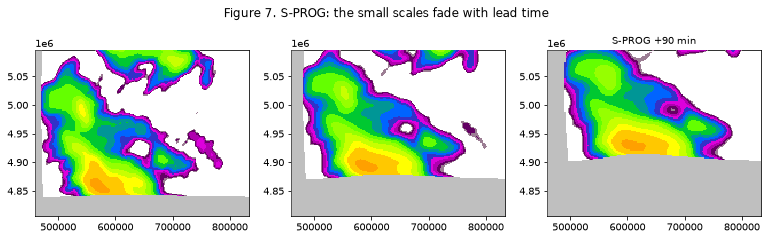

In [10]:
with quiet():
    f_sprog = nowcasts.get_method("sprog")(dbr[i0 - 2:i0 + 1], V_lk, N_LEAD,
                                            n_cascade_levels=N_LEVELS, precip_thr=metadata_db["threshold"])
sprog = transformation.dB_transform(f_sprog, threshold=metadata_db["threshold"], inverse=True)[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for j, k in enumerate((1, 3, 5)):
    plot_precip_field(sprog[k], geodata=metadata, ax=axes[j], colorbar=False,
                      title=f"S-PROG +{(k + 1) * STEP_MIN} min")
fig.suptitle("Figure 7. S-PROG: the small scales fade with lead time")
plt.show()

## 9. ANVIL and LINDA

- **ANVIL** (Pulkkinen et al., 2020) was designed for convective rain. It applies an
  autoregressive model to *vertically integrated liquid* in a cascade, with coefficients
  estimated locally in windows, so growth and decay can differ across the domain. Without
  volumetric radar data it runs on the rain rate, as here and in the training school.
- **LINDA** (Pulkkinen et al., 2021) describes the field as a sum of localised features
  whose evolution follows an integro-difference equation with advection, convolution
  (spreading) and growth/decay. It is the most expressive method in pysteps and by far the
  slowest. pysteps' default feature detector needs scikit-image; we use OpenCV's
  Shi–Tomasi corners instead.

LINDA: 18 s for one nowcast


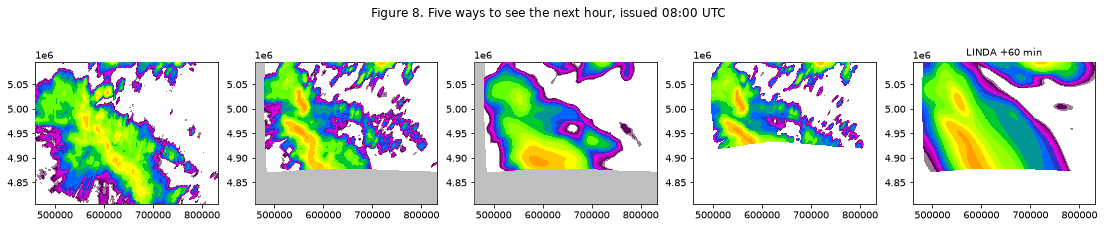

In [11]:
with quiet():
    anvil = np.clip(np.nan_to_num(nowcasts.get_method("anvil")(rate[i0 - 3:i0 + 1], V_lk, N_LEAD, ar_order=2)), 0, None)
t = time.time()
with quiet():
    linda = nowcasts.get_method("linda")(rate[i0 - 2:i0 + 1], V_lk, N_LEAD, feature_method="shitomasi",
                                         max_num_features=15, add_perturbations=False, kmperpixel=KM,
                                         timestep=STEP_MIN, num_workers=4)
linda = np.clip(np.nan_to_num(linda), 0, None)
print(f"LINDA: {time.time() - t:.0f} s for one nowcast")

k = 3
fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
for ax, (title, f) in zip(axes, [("Observed", obs[k]), ("Extrapolation", sl[k]), ("S-PROG", sprog[k]),
                                 ("ANVIL", anvil[k]), ("LINDA", linda[k])]):
    plot_precip_field(f, geodata=metadata, ax=ax, colorbar=False, title=f"{title} +{(k + 1) * STEP_MIN} min")
fig.suptitle("Figure 8. Five ways to see the next hour, issued 08:00 UTC")
plt.show()

## 10. Verifying deterministic nowcasts over many issue times

One case says little; a verification pools many **issue times**. We issue a nowcast every
30 minutes from 05:00 to 11:30 UTC (14 issue times) and score four methods up to 90 min:

- **Eulerian persistence** (the last field, not moved): the baseline any method must beat;
- **extrapolation**, **S-PROG**, **ANVIL** (LINDA is left out of the loop for time).

Scores, all on the verifiable cells of section 7 and pooled over issue times:

- **Categorical**, from the contingency table at a threshold (here 1 mm/h): hits $H$,
  misses $M$, false alarms $F$, correct negatives $C$, and
  $\mathrm{POD} = H/(H+M)$, $\mathrm{FAR} = F/(H+F)$, $\mathrm{CSI} = H/(H+M+F)$, and the
  equitable threat score $\mathrm{ETS} = (H - H_r)/(H + M + F - H_r)$ with
  $H_r = (H+M)(H+F)/N$ the hits expected by chance.
- **Continuous**: mean absolute error (MAE) and Pearson correlation.
- **Fractions skill score** (Roberts & Lean, 2008): compare the *fraction* of pixels above
  the threshold within an $n \times n$ window, $P_f$ and $P_o$;
  $\mathrm{FSS} = 1 - \overline{(P_f - P_o)^2} / (\overline{P_f^2} + \overline{P_o^2})$. It
  rewards forecasts that put rain in roughly the right place at the scale of the window.
  pysteps' `fss` treats missing cells as dry, which would reward everyone for the blank
  inflow cells, so we write a masked version (and check it agrees with pysteps when nothing
  is masked).
- **SAL** (Wernli et al., 2008): Structure, Amplitude and Location errors of rain objects,
  each 0 for a perfect forecast; the implementation is the one in `projects/os_nowcasting`.

In [12]:
from core.nowcast.scores import sal_score

THR = 1.0


class MaskedFSS:
    # fractions skill score accumulated over cases, scored on a mask of valid cells
    def __init__(self, thr, scale):
        self.thr, self.scale, self.num, self.den = thr, scale, 0.0, 0.0

    def accum(self, f, o, valid):
        w = valid.astype(float)
        frac = lambda a: ndimage.uniform_filter((a >= self.thr) * w, self.scale, mode="constant")
        cover = ndimage.uniform_filter(w, self.scale, mode="constant")
        inside = valid & (cover > 0.5)                       # windows mostly inside the valid area
        pf = frac(np.nan_to_num(f)) / np.maximum(cover, 1e-9)
        po = frac(np.nan_to_num(o)) / np.maximum(cover, 1e-9)
        self.num += np.sum((pf - po)[inside] ** 2)
        self.den += np.sum(pf[inside] ** 2 + po[inside] ** 2)

    def compute(self):
        return 1 - self.num / self.den if self.den > 0 else np.nan


chk = MaskedFSS(THR, 5); chk.accum(sl[2], obs[2], np.ones(sl[2].shape, bool))
print("masked FSS, nothing masked: %.3f   pysteps fss: %.3f"
      % (chk.compute(), verification.spatialscores.fss(np.nan_to_num(sl[2]), obs[2], THR, 5)))

masked FSS, nothing masked: 0.721   pysteps fss: 0.723


In [13]:
METHODS = ["persistence", "extrapolation", "sprog", "anvil"]
SCALES = [1, 3, 5, 10, 20]                                   # windows in pixels (x 2 km)
issues = [i for i, t in enumerate(times) if pd.Timestamp("2022-08-18T05:00") <= t <= pd.Timestamp("2022-08-18T11:30")
          and t.minute in (0, 30)]


def run_methods(i):
    with quiet():
        V = motion.get_method("LK")(dbr[i - 3:i + 1], verbose=False)
        d = transformation.dB_transform(rate[i - 3:i + 1], metadata, threshold=0.1, zerovalue=-15.0)[0]
        out = {"persistence": np.repeat(rate[i:i + 1], N_LEAD, axis=0)}
        f = nowcasts.get_method("extrapolation")(d[-1], V, N_LEAD, extrap_kwargs={"allow_nonfinite_values": True})
        out["extrapolation"] = transformation.dB_transform(f, threshold=0.1, inverse=True)[0]
        f = nowcasts.get_method("sprog")(d[-3:], V, N_LEAD, n_cascade_levels=N_LEVELS, precip_thr=0.1)
        out["sprog"] = transformation.dB_transform(f, threshold=0.1, inverse=True)[0]
        f = nowcasts.get_method("anvil")(rate[i - 3:i + 1], V, N_LEAD, ar_order=2)
        out["anvil"] = np.clip(np.nan_to_num(f), 0, None)
    return V, out


cat = {(m, k): verification.det_cat_fct_init(THR) for m in METHODS for k in range(N_LEAD)}
cont = {(m, k): verification.det_cont_fct_init() for m in METHODS for k in range(N_LEAD)}
fss = {(m, s): MaskedFSS(THR, s) for m in METHODS for s in SCALES}
sal = {m: [] for m in METHODS}
t = time.time()
for i in issues:
    V, out = run_methods(i)
    valid = reachable(V, rate.shape[1:], N_LEAD)
    o = rate[i + 1:i + 1 + N_LEAD]
    for m, f in out.items():
        for k in range(N_LEAD):
            fk = np.where(valid[k], f[k], np.nan); ok_ = np.where(valid[k], o[k], np.nan)
            verification.det_cat_fct_accum(cat[m, k], fk, ok_)
            verification.det_cont_fct_accum(cont[m, k], fk, ok_)
        for s in SCALES:
            fss[m, s].accum(f[3], o[3], valid[3])            # 60 min
        sal[m].append(sal_score(np.where(valid[3], np.nan_to_num(f[3]), 0), np.where(valid[3], o[3], 0)))
print(f"{len(issues)} issue times x {len(METHODS)} methods in {time.time() - t:.0f} s")

rows = []
for m in METHODS:
    for k in range(N_LEAD):
        sc = verification.det_cat_fct_compute(cat[m, k], scores=["POD", "FAR", "CSI", "ETS"])
        sc.update(verification.det_cont_fct_compute(cont[m, k], scores=["MAE", "corr_p"]))
        rows.append({"method": m, "lead_min": (k + 1) * STEP_MIN, **{n: float(v) for n, v in sc.items()}})
det = pd.DataFrame(rows)
det.pivot(index="lead_min", columns="method", values="CSI").round(2)

14 issue times x 4 methods in 17 s


method,anvil,extrapolation,persistence,sprog
lead_min,,,,
15,0.72,0.81,0.67,0.82
30,0.62,0.71,0.54,0.73
45,0.57,0.65,0.45,0.68
60,0.52,0.60,0.37,0.64
75,0.49,0.56,0.31,0.61
90,0.45,0.52,0.27,0.58


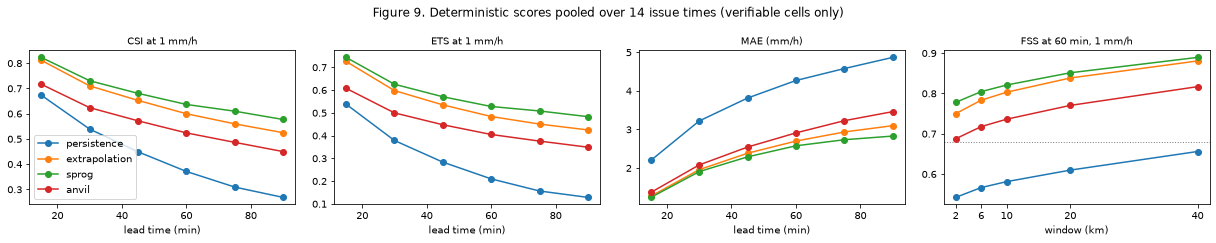

,S,A,L
persistence,-0.03,0.05,0.24
extrapolation,-0.09,-0.11,0.15
sprog,0.03,-0.05,0.16
anvil,-0.09,-0.09,0.18


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.4))
for ax, score in zip(axes[:3], ("CSI", "ETS", "MAE")):
    for m in METHODS:
        d = det[det.method == m]
        ax.plot(d.lead_min, d[score], marker="o", label=m)
    ax.set(xlabel="lead time (min)", title=score + (" (mm/h)" if score == "MAE" else f" at {THR:g} mm/h"))
axes[0].legend()
for m in METHODS:
    axes[3].plot(np.array(SCALES) * KM, [fss[m, s].compute() for s in SCALES], marker="o", label=m)
axes[3].axhline(0.5 + 0.5 * np.mean([np.mean(rate[i] >= THR) for i in issues]), color="grey", ls=":", lw=1)
axes[3].set_xticks(np.array(SCALES) * KM, [f"{s * KM:.0f}" for s in SCALES])
axes[3].set(xlabel="window (km)", title=f"FSS at 60 min, {THR:g} mm/h")
fig.suptitle(f"Figure 9. Deterministic scores pooled over {len(issues)} issue times (verifiable cells only)")
plt.tight_layout(); plt.show()

sal_tab = pd.DataFrame({m: np.nanmean(np.array([s for s in v if s is not None]), axis=0) for m, v in sal.items()},
                       index=["S", "A", "L"]).T.round(2)
sal_tab

**Reading the scores.** Extrapolation beats persistence at every lead: the motion is the
predictable part. S-PROG improves CSI and FSS further by removing scales it can no
longer predict, at the price of a smooth field: in SAL its *structure* error S is the
highest (S > 0 means objects too large and flat), while advecting the observed field
keeps its sharp cells. The dotted line in the FSS panel is the
"useful" level $0.5 + f_o/2$ of Roberts and Lean (2008); a forecast is skilful at the
window size where it crosses it. These numbers come from one event; the nine-storm study
in `projects/os_nowcasting` finds the same ranking (CSI at 60 min against the radar:
persistence 0.27, extrapolation 0.40, S-PROG 0.44 on OpenRainER).

## 11. Ensembles with STEPS and how to verify them

A single nowcast cannot express uncertainty. **STEPS** (Bowler et al., 2006; Seed et al.,
2013) runs the S-PROG cascade but replaces the dropped noise term with spatially
correlated stochastic perturbations, one realisation per member. The training school's
settings, used here:

- `noise_method="nonparametric"`: noise with the observed field's power spectrum;
- `probmatching_method="cdf"`: each member is remapped to the distribution of the last
  observed field, so the ensemble keeps realistic intensities;
- `mask_method="incremental"`: rain may only grow out of existing rain areas gradually;
- `vel_pert_method=None`: no perturbation of the motion field.

**Ensemble scores.** The **CRPS** compares the ensemble's cumulative distribution with the
observation, $\mathrm{CRPS} = \int (F(x) - \mathbb{1}\{x \ge y\})^2\,dx$, in mm/h (lower is
better; it reduces to the MAE for a single member). For the event "rain above 1 mm/h" the
ensemble gives a probability per pixel, verified by the **ROC curve** (hit rate against
false-alarm rate as the probability threshold varies), the **reliability diagram**
(observed frequency against forecast probability; the diagonal is perfect), and the
**rank histogram** (where the observation falls among the sorted members; flat is ideal,
U-shaped means too little spread).

In [15]:
N_MEMBERS = 10
ens_issues = issues[::3]                                  # 5 issue times keep this fast
crps = {k: [] for k in range(N_LEAD)}
LT = 3                                                    # lead index for the probabilistic diagrams (60 min)
roc = verification.ROC_curve_init(THR, n_prob_thrs=10)
rel = verification.reldiag_init(THR)
rank = verification.rankhist_init(N_MEMBERS, THR)
t = time.time()
for i in ens_issues:
    with quiet():
        V = motion.get_method("LK")(dbr[i - 3:i + 1], verbose=False)
        f = nowcasts.get_method("steps")(dbr[i - 2:i + 1], V, N_LEAD, n_ens_members=N_MEMBERS,
                                         n_cascade_levels=N_LEVELS, kmperpixel=KM, precip_thr=0.1,
                                         timestep=STEP_MIN, noise_method="nonparametric",
                                         vel_pert_method=None, probmatching_method="cdf",
                                         mask_method="incremental", seed=1234, num_workers=4)
    ens = transformation.dB_transform(f, threshold=0.1, inverse=True)[0]
    valid = reachable(V, rate.shape[1:], N_LEAD)
    o = rate[i + 1:i + 1 + N_LEAD]
    for k in range(N_LEAD):
        crps[k].append(verification.probscores.CRPS(np.where(valid[k], ens[:, k], np.nan), np.where(valid[k], o[k], np.nan)))
    p = excprob(ens[:, LT], THR, ignore_nan=True)
    o_lt = np.where(valid[LT], o[LT], np.nan)
    verification.ROC_curve_accum(roc, np.where(valid[LT], p, np.nan), o_lt)
    verification.reldiag_accum(rel, np.where(valid[LT], p, np.nan), o_lt)
    verification.rankhist_accum(rank, np.where(valid[LT], ens[:, LT], np.nan), o_lt)
    if i == ens_issues[1]:
        example = (i, ens, o)
print(f"STEPS: {len(ens_issues)} issue times x {N_MEMBERS} members in {time.time() - t:.0f} s")

STEPS: 5 issue times x 10 members in 6 s


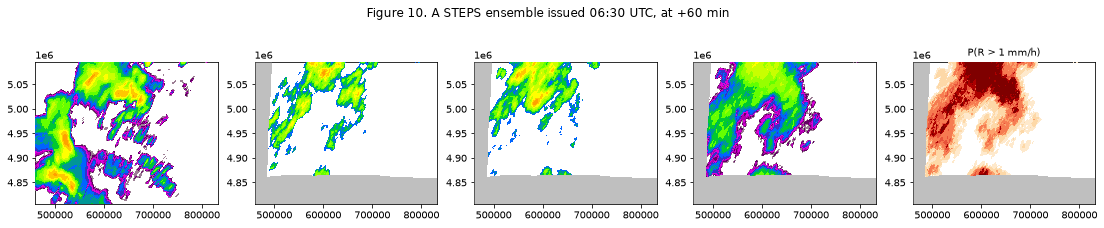

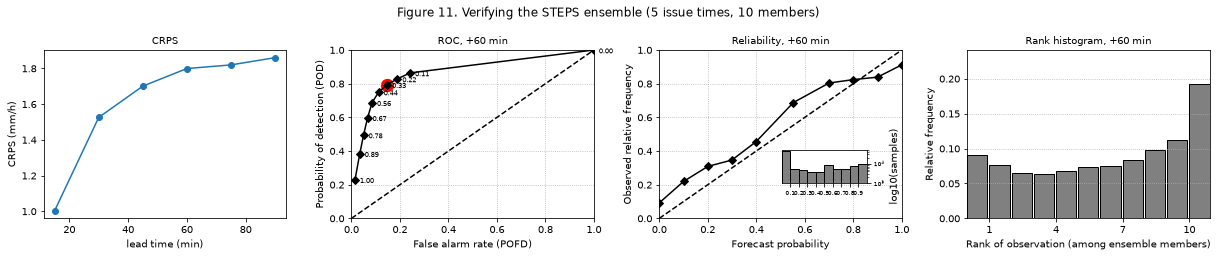

In [16]:
i, ens, o = example
fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
plot_precip_field(o[LT], geodata=metadata, ax=axes[0], colorbar=False, title="Observed +60 min")
plot_precip_field(ens[0, LT], geodata=metadata, ax=axes[1], colorbar=False, title="Member 1")
plot_precip_field(ens[1, LT], geodata=metadata, ax=axes[2], colorbar=False, title="Member 2")
plot_precip_field(ens[:, LT].mean(0), geodata=metadata, ax=axes[3], colorbar=False, title="Ensemble mean")
plot_precip_field(excprob(ens[:, LT], THR, ignore_nan=True), geodata=metadata, ax=axes[4], ptype="prob",
                  units="mm/h", probthr=THR, colorbar=False, title=f"P(R > {THR:g} mm/h)")
fig.suptitle(f"Figure 10. A STEPS ensemble issued {times[i]:%H:%M} UTC, at +60 min")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
axes[0].plot([(k + 1) * STEP_MIN for k in range(N_LEAD)], [np.nanmean(crps[k]) for k in range(N_LEAD)], marker="o")
axes[0].set(xlabel="lead time (min)", ylabel="CRPS (mm/h)", title="CRPS")
verification.plot_ROC(roc, axes[1], opt_prob_thr=True); axes[1].set_title("ROC, +60 min")
verification.plot_reldiag(rel, axes[2]); axes[2].set_title("Reliability, +60 min")
verification.plot_rankhist(rank, axes[3]); axes[3].set_title("Rank histogram, +60 min")
fig.suptitle(f"Figure 11. Verifying the STEPS ensemble ({len(ens_issues)} issue times, {N_MEMBERS} members)")
plt.tight_layout(); plt.show()

The members keep the observed texture, while their mean is smooth like S-PROG. The rank
histogram's raised right end means the observation is often *above every member*, and
the reliability curve lies above the diagonal: rain above 1 mm/h happens more often than
the ensemble says. STEPS with these settings is **under-dispersive and slightly low** on
this growing storm, as the nine-storm study also found (the radar above every member 13%
of the time on OpenRainER). Velocity perturbations (`vel_pert_method="bps"`) are the usual
remedy for too little spread.

## 12. Nowcasting a link map

Can the same machinery nowcast a rain map made from commercial microwave links (CMLs)? We
take OpenMRG (Andersson et al., 2022, [doi:10.5281/zenodo.7107689](https://doi.org/10.5281/zenodo.7107689)):
its example subset includes a reference rain rate per link. We average each link to
5 minutes, interpolate to the radar grid by inverse distance weighting (within 10 km;
tutorial 05 explains the method), and estimate motion on the link maps and on the radar
for the same times.

In [17]:
mrg = example_data.load("openmrg", "8d", components=("radar", "cml"))
t0, t1 = "2015-07-25T04:00", "2015-07-25T10:00"
rad_m = mrg["radar"]["R"].sel(time=slice(t0, t1))                       # mm/h, 5 min, ~2 km grid
print("radar R units:", mrg["radar"]["R"].attrs.get("units"), "| link R units:", mrg["cml"]["R"].attrs.get("units", "mm/h (reference retrieval)"))
cml = mrg["cml"]["R"].sel(time=slice(t0, t1)).mean("sublink_id")         # mm/h per link, 1 min
cml5 = cml.resample(time="5min", label="right", closed="right").mean()
cml5 = cml5.sel(time=rad_m.time)

gx, gy = mrg["radar"]["x_grid"].values, mrg["radar"]["y_grid"].values   # UTM 32N, as the links
lx, ly = mrg["cml"]["x"].values, mrg["cml"]["y"].values                 # link midpoints
dist = np.hypot(gx[..., None] - lx, gy[..., None] - ly)                 # (y, x, link) in m
W = np.where(dist < 10_000, 1.0 / np.maximum(dist, 500.0) ** 2, 0.0)


def idw(values):
    ok = np.isfinite(values)
    w = W[..., ok]
    return np.where(w.sum(-1) > 0, (w * values[ok]).sum(-1) / np.maximum(w.sum(-1), 1e-12), np.nan)


cml_map = np.stack([idw(v) for v in cml5.transpose("time", "cml_id").values])
rad_arr = rad_m.values
dy_m = abs(float(np.diff(mrg["radar"]["y"].values[:2])[0]))
meta_m = {"xpixelsize": dy_m, "ypixelsize": dy_m, "yorigin": "upper", "accutime": 5.0, "unit": "mm/h",
          "transform": None, "threshold": 0.1, "zerovalue": 0.0}
cover = np.isfinite(cml_map).mean(0) > 0.99
print(f"radar grid {rad_arr.shape[1:]}, {dy_m / 1000:.1f} km pixels; link map covers {cover.mean():.0%} of it")

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


radar R units: mm/h | link R units: mm/h (reference retrieval)


radar grid (48, 37), 2.0 km pixels; link map covers 63% of it


In [18]:
def lk(seq, meta):
    d = transformation.dB_transform(np.nan_to_num(seq), meta, threshold=0.1, zerovalue=-15.0)[0]
    with quiet():
        return motion.get_method("LK")(d, verbose=False)


km_per_px, step = dy_m / 1000, 5
rows = []
for i in range(6, len(rad_m.time), 6):                                   # every 30 min
    Vr, Vc = lk(rad_arr[i - 3:i + 1], meta_m), lk(cml_map[i - 3:i + 1], meta_m)
    vr, vc = np.nanmean(Vr[:, cover], axis=1), np.nanmean(Vc[:, cover], axis=1)
    to_kmh = km_per_px * 60 / step
    rows.append({"time": pd.Timestamp(rad_m.time.values[i]), "radar km/h": np.hypot(*vr) * to_kmh,
                 "links km/h": np.hypot(*vc) * to_kmh, "difference km/h": np.hypot(*(vr - vc)) * to_kmh})
mot = pd.DataFrame(rows).set_index("time").round(1)
mot

,radar km/h,links km/h,difference km/h
time,,,
2015-07-25 04:30:00,10.1,0.5,10.5
2015-07-25 05:00:00,16.9,6.0,22.8
2015-07-25 05:30:00,25.6,0.0,25.6
2015-07-25 06:00:00,30.4,10.2,21.3
2015-07-25 06:30:00,26.4,7.3,19.6
2015-07-25 07:00:00,40.2,8.3,34.0
2015-07-25 07:30:00,39.3,5.6,33.8
2015-07-25 08:00:00,61.7,0.5,61.2
2015-07-25 08:30:00,50.7,1.0,49.7


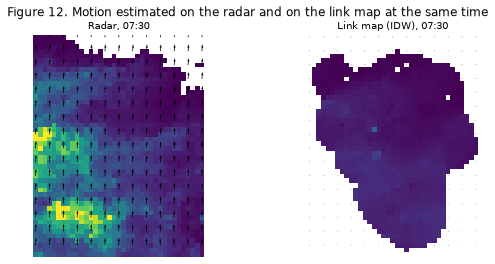

In [19]:
k = int(np.argmin(np.abs(rad_m.time.values - np.datetime64("2015-07-25T07:30"))))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, f, V) in zip(axes, [("Radar", rad_arr, lk(rad_arr[k - 3:k + 1], meta_m)),
                                     ("Link map (IDW)", cml_map, lk(cml_map[k - 3:k + 1], meta_m))]):
    ax.imshow(np.ma.masked_less(np.nan_to_num(f[k]), 0.1), cmap="viridis", vmax=15)
    ax.quiver(np.arange(0, f.shape[2], 3), np.arange(0, f.shape[1], 3), V[0, ::3, ::3], -V[1, ::3, ::3], scale=40)
    ax.set_title(f"{title}, {pd.Timestamp(rad_m.time.values[k]):%H:%M}"); ax.axis("off")
fig.suptitle("Figure 12. Motion estimated on the radar and on the link map at the same time")
plt.show()

The motion estimated on the link map is close to zero while the radar's is 10–60 km/h,
so the two differ by about the radar's own speed.
A link map is not an image of the rain: rain *appears* where links happen to be and
vanishes between them, so optical flow tracks the network's pattern of switching on and
off rather than the storm. Across nine storms in `projects/os_nowcasting`, extrapolating a
link map scored no better than holding it still (CSI 0.16 vs 0.17), whereas a map that
merges links into the radar keeps the radar's motion. To nowcast with links, estimate
motion on the radar (or on a merged product) and use the links to correct intensities.

## 13. Advection interpolation for accumulations

The same motion field improves **accumulations**. An hourly total from 5-minute radar
scans treats each scan as the rate for its whole interval, so a fast cell leaves a string
of beads instead of a swath. Interpolating between consecutive scans along the motion
(block 03a of the training school),

$$R(t_0 + a\Delta t) \approx (1 - a)\, R_0(\mathbf{x} - a\mathbf{V}) + a\, R_1\big(\mathbf{x} + (1 - a)\mathbf{V}\big),\qquad 0 < a < 1,$$

fills the gaps. It applies to *instantaneous* scans such as OpenMRG's; OpenRainER's
15-minute depths are already time integrals.

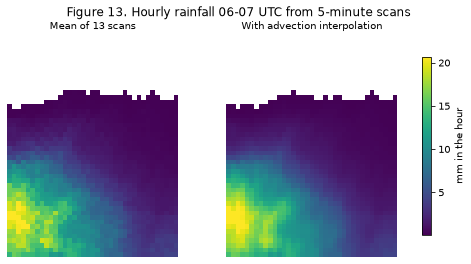

In [20]:
from core.nowcast.advection import hourly_total

hour = slice("2015-07-25T06:00", "2015-07-25T07:00")
scans = mrg["radar"]["R"].sel(time=hour).values                      # 13 scans, both ends
# motion over the hour, Lucas-Kanade on dBR as in section 4
dbr, _ = transformation.dB_transform(np.nan_to_num(scans), threshold=0.1, zerovalue=-15.0)
with quiet():
    velocity = motion.get_method("LK")(dbr, verbose=False)
plain = hourly_total(scans)                          # mean of the scans
smooth = hourly_total(scans, velocity, n_sub=10)     # plus 9 advected frames per interval
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, f) in zip(axes, [("Mean of 13 scans", plain), ("With advection interpolation", smooth)]):
    im = ax.imshow(np.ma.masked_less(f, 0.1), cmap="viridis", vmax=np.nanpercentile(plain, 99.5))
    ax.set_title(title); ax.axis("off")
fig.colorbar(im, ax=axes, label="mm in the hour", shrink=0.8)
fig.suptitle("Figure 13. Hourly rainfall 06-07 UTC from 5-minute scans")
plt.show()

The interpolated total is a smooth swath. At OpenMRG's city gauges the effect on hourly
totals over five storms is small (RMSE 1.19 to 1.15 mm, `projects/os_nowcasting`), since
the gauges sit where the beads overlap often; it matters most for fast, small cells and
coarse scan intervals.

## 14. Summary

- pysteps needs rain *rates* in a `(time, y, x)` array and a metadata dictionary with the
  pixel size, `yorigin` and units; motion is estimated in dBR.
- Optical flow recovers motion from consecutive images; Lucas–Kanade is fast and robust,
  VET and Proesmans agree with it, DARTS needs tuning on small grids.
- Lagrangian persistence beats Eulerian persistence because motion is the predictable part.
  S-PROG adds scale-dependent decay and gains skill by smoothing; STEPS adds noise to give
  an ensemble with realistic texture, under-dispersive with the default settings.
- Score only cells reachable from inside the domain; otherwise the inflow edge dominates.
- Link maps do not carry usable motion; take motion from the radar or a merged map.

**Next:** [08 · Learned nowcasting](08_learned_nowcasting.ipynb) trains a small neural
network on the same radar and compares it with the methods above. The nine-storm study
is in [`projects/os_nowcasting`](../projects/os_nowcasting/README.md).

In [21]:
print(f"Notebook run time: {(time.time() - T0) / 60:.1f} min")

Notebook run time: 1.0 min


## 15. References and links

**Software and material**
- pysteps documentation: <https://pysteps.readthedocs.io/en/stable/> · example gallery: <https://pysteps.readthedocs.io/en/stable/auto_examples/index.html>
- OpenSense training school 2025, nowcasting session (J. Ritvanen, R. Imhoff): <https://github.com/OpenSenseAction/TrainingSchoolMergingApplication/tree/main/nowcasting-session>
- FieldSense nowcasting study: [`projects/os_nowcasting`](../projects/os_nowcasting/README.md)
- OpenSense example data: <https://github.com/OpenSenseAction/opensense_example_data>

**Data**
- Covi, E. and Roversi, G.: OpenRainER, Emilia-Romagna CML, gauges and radar. <https://doi.org/10.5281/zenodo.10593848>
- Andersson, J. C. M. et al. (2022): OpenMRG, Gothenburg CML, radar and gauges. <https://doi.org/10.5281/zenodo.7107689>

**Methods**
- Pulkkinen, S. et al. (2019): Pysteps: an open-source Python library for probabilistic precipitation nowcasting (v1.0). *Geosci. Model Dev.*, 12, 4185–4219. <https://doi.org/10.5194/gmd-12-4185-2019>
- Germann, U. and Zawadzki, I. (2002): Scale-dependence of the predictability of precipitation from continental radar images. Part I. *Mon. Wea. Rev.*, 130, 2859–2873. <https://doi.org/10.1175/1520-0493(2002)130%3C2859:SDOTPO%3E2.0.CO;2>
- Seed, A. W. (2003): A dynamic and spatial scaling approach to advection forecasting (S-PROG). *J. Appl. Meteor.*, 42, 381–388. <https://doi.org/10.1175/1520-0450(2003)042%3C0381:ADASSA%3E2.0.CO;2>
- Bowler, N. E., Pierce, C. E. and Seed, A. W. (2006): STEPS. *Q. J. R. Meteorol. Soc.*, 132, 2127–2155. <https://doi.org/10.1256/qj.04.100>
- Seed, A. W., Pierce, C. E. and Norman, K. (2013): Formulation and evaluation of a scale decomposition-based stochastic precipitation nowcast scheme. *Water Resour. Res.*, 49, 6624–6641. <https://doi.org/10.1002/wrcr.20536>
- Pulkkinen, S. et al. (2020): Nowcasting of convective rainfall using volumetric radar observations (ANVIL). *IEEE Trans. Geosci. Remote Sens.* <https://doi.org/10.1109/TGRS.2020.2984594>
- Pulkkinen, S., Chandrasekar, V. and Niemi, T. (2021): Lagrangian integro-difference equation model for precipitation nowcasting (LINDA). *J. Atmos. Oceanic Technol.*, 38(12), 2125–2145. <https://doi.org/10.1175/JTECH-D-21-0013.1>
- Bouguet, J.-Y. (2001): Pyramidal implementation of the affine Lucas Kanade feature tracker. Intel Corporation.
- Laroche, S. and Zawadzki, I. (1995): Retrievals of horizontal winds from single-Doppler clear-air data by methods of cross correlation and variational analysis (VET). *J. Atmos. Oceanic Technol.*, 12, 721–738. <https://doi.org/10.1175/1520-0426(1995)012%3C0721:ROHWFS%3E2.0.CO;2>
- Ruzanski, E., Chandrasekar, V. and Wang, Y. (2011): The CASA nowcasting system (DARTS). *J. Atmos. Oceanic Technol.*, 28, 640–655. <https://doi.org/10.1175/2011JTECHA1496.1>
- Proesmans, M. et al. (1994): Determination of optical flow and its discontinuities using non-linear diffusion. *ECCV '94*, LNCS 801, 294–304.
- Roberts, N. M. and Lean, H. W. (2008): Scale-selective verification of rainfall accumulations (FSS). *Mon. Wea. Rev.*, 136, 78–97. <https://doi.org/10.1175/2007MWR2123.1>
- Wernli, H. et al. (2008): SAL - a novel quality measure for the verification of quantitative precipitation forecasts. *Mon. Wea. Rev.*, 136, 4470–4487. <https://doi.org/10.1175/2008MWR2415.1>